Código equivalente ao código anterior, mas agora com uma rede neural de duas camadas, onde cada camada tem um neurônio. A primeira camada recebe as entradas, e a segunda camada recebe a saída da primeira camada como entrada. Vamos usar o mesmo dataset fictício (problema XOR) e permitir a escolha de funções de ativação.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Funções de ativação
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# Derivadas das funções de ativação (para o gradiente)
def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

# Dataset fictício (problema de classificação binária)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # Entradas
y = np.array([[0], [1], [1], [0]])              # Saídas esperadas (XOR)

# Hiperparâmetros
learning_rate = 0.2
epochs = 1000000

# Inicialização dos pesos e viés
np.random.seed(42)
# Camada 1: 2 entradas -> 1 neurônio
weights_1 = np.random.randn(2, 1)
bias_1 = np.random.randn()

# Camada 2: 1 entrada (saída da camada 1) -> 1 neurônio
weights_2 = np.random.randn(1, 1)
bias_2 = np.random.randn()

# Escolha da função de ativação
activation_function = sigmoid
activation_derivative = sigmoid_derivative

# Treinamento da rede
errors = []
for epoch in range(epochs):
    # Forward pass
    # Camada 1
    weighted_sum_1 = np.dot(X, weights_1) + bias_1
    output_1 = activation_function(weighted_sum_1)

    # Camada 2
    weighted_sum_2 = np.dot(output_1, weights_2) + bias_2
    output_2 = activation_function(weighted_sum_2)

    # Cálculo do erro (erro quadrático médio)
    error = y - output_2
    errors.append(np.mean(np.square(error)))

    # Backpropagation
    # Gradiente da camada 2
    d_error = -2 * error / len(X)
    d_output_2 = activation_derivative(weighted_sum_2)
    gradient_2 = d_error * d_output_2

    # Gradiente da camada 1
    d_output_1 = activation_derivative(weighted_sum_1)
    gradient_1 = np.dot(gradient_2, weights_2.T) * d_output_1

    # Atualização dos pesos e viés
    weights_2 -= learning_rate * np.dot(output_1.T, gradient_2)
    bias_2 -= learning_rate * np.sum(gradient_2)

    weights_1 -= learning_rate * np.dot(X.T, gradient_1)
    bias_1 -= learning_rate * np.sum(gradient_1)

    # Exibir progresso a cada 1000 épocas
    if epoch % 1000 == 0:
        print(f"Época {epoch}, Erro: {errors[-1]}")


Época 0, Erro: 0.2886287602318518
Época 1000, Erro: 0.24992862174746608
Época 2000, Erro: 0.24894763138208037
Época 3000, Erro: 0.23934542257797153
Época 4000, Erro: 0.20531820830160186
Época 5000, Erro: 0.18355052828249852
Época 6000, Erro: 0.17641383038613062
Época 7000, Erro: 0.17333299809066874
Época 8000, Erro: 0.17167625355022822
Época 9000, Erro: 0.17065631360065667
Época 10000, Erro: 0.16997027232089434
Época 11000, Erro: 0.16947936834591948
Época 12000, Erro: 0.16911175052542288
Época 13000, Erro: 0.1688267157524621
Época 14000, Erro: 0.16859957068134113
Época 15000, Erro: 0.16841450494145394
Época 16000, Erro: 0.1682609457693593
Época 17000, Erro: 0.16813156517972744
Época 18000, Erro: 0.16802112953070414
Época 19000, Erro: 0.16792580450569286
Época 20000, Erro: 0.16784271874549941
Época 21000, Erro: 0.16776968067246836
Época 22000, Erro: 0.16770498938482947
Época 23000, Erro: 0.16764730516237863
Época 24000, Erro: 0.1675955588056122
Época 25000, Erro: 0.16754888689932076
Épo

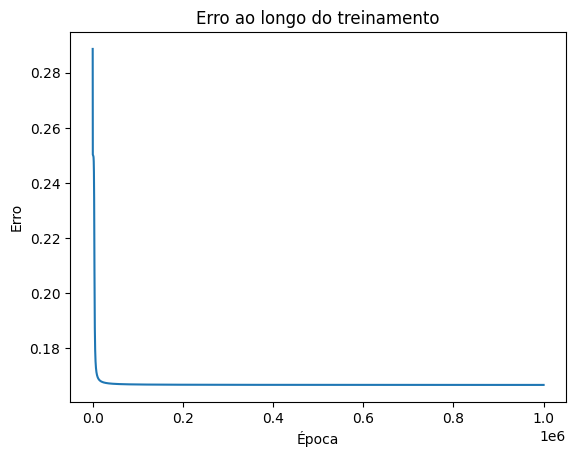


Teste da rede treinada:
Entrada: [0 0], Saída esperada: [0], Saída da rede: [0.00426992]
Entrada: [0 1], Saída esperada: [1], Saída da rede: [0.66664795]
Entrada: [1 0], Saída esperada: [1], Saída da rede: [0.66664795]
Entrada: [1 1], Saída esperada: [0], Saída da rede: [0.6666825]


In [14]:
# Plot do erro ao longo do treinamento
plt.plot(range(epochs), errors)
plt.title("Erro ao longo do treinamento")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.show()

# Teste da rede treinada
print("\nTeste da rede treinada:")
for i in range(len(X)):
    # Forward pass
    weighted_sum_1 = np.dot(X[i], weights_1) + bias_1
    output_1 = activation_function(weighted_sum_1)

    weighted_sum_2 = np.dot(output_1, weights_2) + bias_2
    output_2 = activation_function(weighted_sum_2)

    print(f"Entrada: {X[i]}, Saída esperada: {y[i]}, Saída da rede: {output_2}")